# CCD Optimization: LLM Prompts + DINOv2 Label Propagation
**Paper:** Classifier-guided CLIP Distillation (CVPR 2025)

**Contributions:**
1. LLM-enriched hybrid prompt embeddings (α-blending)
2. DINOv2 visual-similarity label propagation
3. Combined LLM+DINOv2 approach


## Part 1: Environment Setup

In [1]:
import os
CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
os.makedirs(os.path.expanduser('~/CCD_Project'), exist_ok=True)
if not os.path.exists(CCD_DIR):
    !git clone https://github.com/k0u-id/CCD.git {CCD_DIR}
else:
    print('Repo already cloned.')
!pip install -q munch tqdm scikit-learn ftfy regex

Repo already cloned.


In [2]:
import os
CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
os.chdir(CCD_DIR)
os.makedirs('pretrained', exist_ok=True)
clip_path = 'pretrained/RN50x64.pt'
if not os.path.exists(clip_path):
    print('Downloading CLIP RN50x64 (~600MB)...')
    !wget -q https://openaipublic.azureedge.net/clip/models/be1cfb55d75a9666199fb2206c106743da0f6468c9d327f3e0d0a543a9919d9c/RN50x64.pt -O {clip_path}
    print('Done!')
else:
    print('CLIP model already downloaded.')

CLIP model already downloaded.


In [3]:
import os, shutil
CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
os.chdir(CCD_DIR)
os.makedirs('data/pascal/JPEGImages', exist_ok=True)
os.makedirs('data/pascal/Annotations', exist_ok=True)
os.makedirs('data/pascal/ImageSets', exist_ok=True)
count = len(os.listdir('data/pascal/JPEGImages')) if os.path.exists('data/pascal/JPEGImages') else 0
if count < 9900:
    print(f'Only {count} images found. Downloading from Kaggle...')
    !pip install -q kagglehub
    import kagglehub
    path = kagglehub.dataset_download('zaraks/pascal-voc-2007')
    for root, dirs, files in os.walk(path):
        if os.path.basename(root) == 'JPEGImages':
            for f in os.listdir(root): shutil.copy2(os.path.join(root, f), os.path.join('data/pascal/JPEGImages', f))
        if os.path.basename(root) == 'Annotations':
            for f in os.listdir(root): shutil.copy2(os.path.join(root, f), os.path.join('data/pascal/Annotations', f))
        if os.path.basename(root) == 'ImageSets':
            shutil.copytree(root, 'data/pascal/ImageSets', dirs_exist_ok=True)
    count = len(os.listdir('data/pascal/JPEGImages'))
print(f'Total images: {count}')
assert count >= 9900, f'Expected ~9963 images, got {count}'

Total images: 9963


In [4]:
import os
CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
os.chdir(CCD_DIR)
os.makedirs('metadata/voc07', exist_ok=True)
!pip install -q gdown
!gdown --folder https://drive.google.com/drive/folders/1gbTkK4pEN83UbsNCBIXap1MBdb3XwgHA -O metadata/voc07/
print('Metadata files:')
!ls metadata/voc07/

Retrieving folder contents
Processing file 1mQUvxMnfU-yRtyb9cvskCAsrTHBQ2q2z formatted_train_images.npy
Processing file 1h8-18Xw5EUciB1xICM30BRnRISunf-eJ formatted_train_labels.npy
Processing file 1MJOPkzI5YAeL5zK-67eWCB2yDK-UP0yw formatted_val_images.npy
Processing file 1oK6bM1KblaN6b9NUhqtKWH2ufh3rUu3b formatted_val_labels.npy
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1mQUvxMnfU-yRtyb9cvskCAsrTHBQ2q2z
To: /teamspace/studios/this_studio/CCD_Project/CCD/metadata/voc07/voc07/formatted_train_images.npy
100%|████████████████████████████████████████| 201k/201k [00:00<00:00, 16.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1h8-18Xw5EUciB1xICM30BRnRISunf-eJ
To: /teamspace/studios/this_studio/CCD_Project/CCD/metadata/voc07/voc07/formatted_train_labels.npy
100%|████████████████████████████████████████| 802k/802k [00:00<00:00, 32.1MB/s]
Downloading...
From: https://dri

In [5]:
import os
CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
os.chdir(CCD_DIR)
with open('datasets.py', 'r') as f: code = f.read()
code = code.replace("'/home/datasets/", f"'{CCD_DIR}/data/")
code = code.replace("'/data/datasets/", f"'{CCD_DIR}/data/")
with open('datasets.py', 'w') as f: f.write(code)
print('✅ datasets.py paths fixed!')

✅ datasets.py paths fixed!


In [6]:
import os, numpy as np
CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
checks = {
    'CLIP model': os.path.exists(f'{CCD_DIR}/pretrained/RN50x64.pt'),
    'Images (9900+)': len(os.listdir(f'{CCD_DIR}/data/pascal/JPEGImages')) >= 9900,
    'Train metadata': os.path.exists(f'{CCD_DIR}/metadata/voc07/formatted_train_images.npy'),
    'Test metadata': os.path.exists(f'{CCD_DIR}/metadata/voc07/formatted_val_images.npy'),
}
for name, ok in checks.items(): print(f"{'✅' if ok else '❌'} {name}")
if all(checks.values()): print('\n🚀 All checks passed!')
else: print('\n⚠️ Fix the issues above before proceeding.')

✅ CLIP model
✅ Images (9900+)
✅ Train metadata
✅ Test metadata

🚀 All checks passed!


In [7]:
os.chdir(CCD_DIR)

# Read the original datasets.py
with open('datasets.py', 'r') as f:
    content = f.read()

# Fix the hardcoded paths
content = content.replace(
    "'path_to_images': '/data/data/VOC2007/JPEGImages'",
    "'path_to_images': './data/pascal/JPEGImages'"
)
content = content.replace(
    "'path_to_images': '/data/data/VOC2012/JPEGImages'",
    "'path_to_images': './data/pascal/JPEGImages'"
)

with open('datasets.py', 'w') as f:
    f.write(content)

print('Fixed dataset paths!')

Fixed dataset paths!


## Part 2: Baseline Training (Original CCD)

In [1]:
import os, shutil
import subprocess

CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
os.chdir(CCD_DIR)

print("="*60)
print("🔴 RUNNING COMPLETELY CLEAN BASELINE (No LLM, No DINOv2)")
print("="*60)

# 1. Temporarily HIDE our improvement files so the script cannot find them
# This forces train.py to use standard CLIP prompts and skip DINOv2
if os.path.exists('enriched_embeddings_voc07.pt'):
    os.rename('enriched_embeddings_voc07.pt', 'enriched_embeddings_voc07.pt.hidden')
if os.path.exists('dinov2_propagation_data.pt'):
    os.rename('dinov2_propagation_data.pt', 'dinov2_propagation_data.pt.hidden')

# 2. Run the original training command
CMD = ("python main_multi.py --dataset voc07 --num_epochs 10 --bsize 16 --lr 1e-5 "
       "--offset_size 80 --coeff 3 --loss_coeff 1 --ratio 0.2 "
       "--box_offset 80 --topk 1 --LS True --LS_coeff 20 --bound 4")

# Run it! (Takes ~20 mins)
subprocess.run(CMD, shell=True, check=True)

# 3. Save this fresh baseline to a brand NEW folder
results_dir = os.path.join(CCD_DIR, 'results')
folders = sorted([f for f in os.listdir(results_dir) if f.startswith('202')])

if folders:
    # Save it as 'pure_baseline' so it doesn't overwrite your old 'baseline'
    dst = os.path.join(results_dir, 'pure_baseline') 
    if os.path.exists(dst): 
        shutil.rmtree(dst)
    shutil.move(os.path.join(results_dir, folders[-1]), dst)
    print(f"\n✅ Fresh baseline saved securely to: results/pure_baseline/")
else:
    print("\n❌ Training didn't produce a new folder.")

# 4. RESTORE our improvement files so you don't lose them for future runs!
if os.path.exists('enriched_embeddings_voc07.pt.hidden'):
    os.rename('enriched_embeddings_voc07.pt.hidden', 'enriched_embeddings_voc07.pt')
if os.path.exists('dinov2_propagation_data.pt.hidden'):
    os.rename('dinov2_propagation_data.pt.hidden', 'dinov2_propagation_data.pt')
    
print("🔄 Restored improvement files for your next experiments.")


/teamspace/studios/this_studio/CCD_Project/CCD/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging
Munch({'dataset': 'voc07', 'num_epochs': 10, 'gpu_num': '0', 'bsize': 16, 'lr': 1e-05, 'offset_size': 80, 'coeff': 3.0, 'loss_coeff': 1.0, 'ratio': 0.2, 'colorjitter': True, 'update_label': True, 'train_resize': (448, 448), 'patch_resize': (640, 640), 'box_offset': 80, 'topk': 1, 'LS': True, 'coeff_bias': False, 'method': 'cam_based', 'arch': 'resnet101', 'inf_num': 1, 'global_temp': True, 'local_temp': True, 'use_consist': 1, 'LS_coeff': 20, 'bound': 4, 'ss_seed': 999, 'ss_frac_train': 1.0, 'ss_frac_val': 1.0, 'use_feats': False, 'val_frac': 0.2, 'split_seed': 1200, 'train_set_variant': 'observed', 'val_set_variant': 'clean', 'freeze_feature_extrac

## Part 3: Contribution 1 — LLM-Enriched Hybrid Prompts
Generate hybrid embeddings by blending baseline CLIP prompts with rich LLM-generated visual descriptions.

In [2]:
import os, sys, torch
CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
os.chdir(CCD_DIR)
sys.path.insert(0, CCD_DIR)
import clip

device = 'cuda'
clip_model, _ = clip.load('./pretrained/RN50x64.pt', device=device)

pascal_classes = [
    'aeroplane','bicycle','bird','boat','bottle','bus','car','cat',
    'chair','cow','dining table','dog','horse','motorbike','person',
    'potted plant','sheep','sofa','train','tv monitor'
]

# Baseline embeddings
baseline_weights = []
with torch.no_grad(), torch.cuda.amp.autocast():
    for classname in pascal_classes:
        texts = clip.tokenize([f'a photo of the {classname}']).to(device)
        feat = clip_model.encode_text(texts)
        feat /= feat.norm(dim=-1, keepdim=True)
        feat = feat.mean(dim=0)
        feat /= feat.norm()
        baseline_weights.append(feat)
baseline_weights = torch.stack(baseline_weights, dim=0)

# LLM-enriched descriptions (5 rich visual descriptions per class)
llm_descriptions = {
    'aeroplane': ['a large aircraft with wings flying in the sky','a jet plane with a fuselage, tail fin, and engines on a runway','an airplane soaring above the clouds with visible wings','a commercial or military aircraft photographed from below','a flying vehicle with a metallic body and windows along its side'],
    'bicycle': ['a two-wheeled vehicle with pedals, handlebars, and a seat','a bicycle with thin tires leaning against a wall or fence','a person riding a bike with spoked wheels on a road','a pedal-powered vehicle with a chain, gears, and frame','a parked or moving bicycle with a basket or rack'],
    'bird': ['a small feathered animal perched on a branch or wire','a flying creature with wings spread in the air','a bird with a beak, feathers, and clawed feet on the ground','a colorful or dark-plumed avian sitting in a tree','a wild or domestic bird near water, food, or a nest'],
    'boat': ['a watercraft floating on a lake, river, or ocean','a small sailing boat with a mast and sails on water','a motorboat or rowboat docked at a pier or harbor','a vessel with a hull moving through waves','a canoe, kayak, or yacht seen from shore or above'],
    'bottle': ['a glass or plastic container with a narrow neck and cap','a beverage bottle sitting on a table or shelf','a transparent or colored bottle holding liquid','a wine, water, or soda bottle with a label','a cylindrical container with a lid used for drinking'],
    'bus': ['a large public transport vehicle with many windows and seats','a city bus or school bus on a road picking up passengers','a long rectangular vehicle painted in bright colors','a double-decker or single-level bus at a bus stop','a big passenger vehicle with wheels and a flat front'],
    'car': ['a four-wheeled motor vehicle on a street or parking lot','a sedan, SUV, or hatchback with headlights and bumpers','an automobile with doors, windows, and a roof driving on a road','a parked or moving car in an urban or suburban setting','a personal vehicle with side mirrors and license plates'],
    'cat': ['a small furry domestic animal with pointed ears and whiskers','a cat sitting, sleeping, or playing indoors','a feline pet with soft fur, a tail, and green or yellow eyes','a kitten or adult cat grooming itself or looking at the camera','a house cat lying on furniture or near a window'],
    'chair': ['a piece of furniture with a seat, backrest, and four legs','a wooden, metal, or plastic chair at a desk or table','an office chair with wheels and armrests','a dining chair or folding chair in a room','a seat designed for one person to sit on'],
    'cow': ['a large farm animal with horns, hooves, and a spotted hide','a dairy cow grazing in a green pasture or field','a bovine with black and white or brown patches standing on grass','a herd of cattle near a barn or fence','a domestic cow with an udder and a broad face'],
    'dining table': ['a large flat-surfaced table with plates, glasses, and food on it','a wooden or glass dining table surrounded by chairs','a table set for a meal in a kitchen or restaurant','a rectangular or round table with tableware and cutlery','a piece of furniture used for eating with items on top'],
    'dog': ['a furry domestic pet with four legs, a tail, and floppy ears','a dog sitting, running, or playing outdoors on grass','a canine with a collar and leash being walked by a person','a puppy or adult dog with a snout, paws, and expressive eyes','a loyal pet animal barking, fetching, or resting indoors'],
    'horse': ['a large four-legged animal with a mane and long tail','a horse galloping, trotting, or standing in a field','an equine with a saddle and bridle being ridden by a person','a brown, black, or white horse grazing near a fence','a muscular animal with hooves used for riding or racing'],
    'motorbike': ['a two-wheeled motorized vehicle with an engine and handlebars','a motorcycle parked on a street or being ridden at speed','a motorbike with a rider wearing a helmet on a highway','a sport bike or cruiser with chrome parts and exhaust pipes','a powered two-wheeler with a seat, mirrors, and headlamp'],
    'person': ['a human being standing, walking, or sitting in a scene','a man, woman, or child with visible face, arms, and clothing','a person engaged in an activity like eating, working, or playing','a pedestrian on a street or an individual posing for a photo','a human figure with hair, skin, and wearing shoes or accessories'],
    'potted plant': ['a green plant growing in a flower pot or container','a houseplant with leaves sitting on a windowsill or table','a decorative potted plant with soil visible in a ceramic pot','a small tree or bush planted in a garden pot indoors','a flowering or leafy plant in a terracotta or plastic planter'],
    'sheep': ['a woolly farm animal standing in a green meadow or pasture','a flock of sheep with thick white fleece grazing on a hillside','a lamb or adult sheep with a round body and short legs','a domestic animal with curly wool and a flat face near a fence','a group of sheep herded by a dog or shepherd in a field'],
    'sofa': ['a large cushioned piece of furniture for sitting or lying on','a couch with pillows and armrests in a living room','a soft upholstered sofa in front of a TV or coffee table','a two or three-seater settee with fabric or leather covering','a comfortable piece of furniture people sit or relax on indoors'],
    'train': ['a long railway vehicle running on tracks at a station','a passenger or freight train with multiple carriages','a locomotive with wheels on rails moving through a landscape','a subway, metro, or intercity train at a platform','a large transport vehicle on railroad tracks with people nearby'],
    'tv monitor': ['a flat-screen television or computer monitor displaying an image','a rectangular electronic screen on a desk or wall mount','a TV set showing a program in a living room or bedroom','a display device with a bezel and stand used for watching or computing','a glowing screen with pixels showing video content'],
}

llm_weights = []
with torch.no_grad(), torch.cuda.amp.autocast():
    for classname in pascal_classes:
        texts = clip.tokenize(llm_descriptions[classname]).to(device)
        feat = clip_model.encode_text(texts)
        feat /= feat.norm(dim=-1, keepdim=True)
        feat = feat.mean(dim=0)
        feat /= feat.norm()
        llm_weights.append(feat)
llm_weights = torch.stack(llm_weights, dim=0)

# Save hybrid blends for ablation
for alpha in [0.3, 0.5, 0.7]:
    hybrid = alpha * baseline_weights + (1 - alpha) * llm_weights
    hybrid /= hybrid.norm(dim=-1, keepdim=True)
    torch.save({'text_weights': hybrid.permute(1, 0).cpu(), 'class_names': pascal_classes, 'alpha': alpha},
               f'enriched_embeddings_voc07_alpha{alpha}.pt')
    print(f'✅ alpha={alpha} ({alpha*100:.0f}% baseline + {(1-alpha)*100:.0f}% LLM)')

del clip_model; torch.cuda.empty_cache()
print('\n📦 Hybrid embeddings ready!')

/teamspace/studios/this_studio/CCD_Project/CCD/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging
/tmp/ipykernel_1713/958431791.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():
/tmp/ipykernel_1713/958431791.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


✅ alpha=0.3 (30% baseline + 70% LLM)
✅ alpha=0.5 (50% baseline + 50% LLM)
✅ alpha=0.7 (70% baseline + 30% LLM)

📦 Hybrid embeddings ready!


In [3]:
# Patch train.py to support enriched embeddings
import os
CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
os.chdir(CCD_DIR)

with open('train.py', 'r') as f: lines = f.readlines()
if 'enriched_embeddings' in ''.join(lines):
    print('✅ Already patched for LLM embeddings!')
else:
    start_idx = end_idx = None
    for i, line in enumerate(lines):
        if 'torch.no_grad()' in line and 'autocast()' in line and start_idx is None: start_idx = i
        if 'text_weights.permute(1, 0)' in line and start_idx is not None: end_idx = i; break
    if start_idx and end_idx:
        new_block = [
            "    # === Load LLM-enriched embeddings if available ===\n",
            "    enriched_path = './enriched_embeddings_voc07.pt'\n",
            "    if os.path.exists(enriched_path):\n",
            "        print(f'[LLM] Loading enriched embeddings from {enriched_path}')\n",
            "        emb_data = torch.load(enriched_path, map_location=device)\n",
            "        text_weights = emb_data['text_weights'].to(device)\n",
            "        text_weights = text_weights.permute(1, 0)\n",
            "        print(f'  Shape: {text_weights.shape}')\n",
            "    else:\n",
            "        print('[BASELINE] Using standard CLIP prompts')\n"
        ]
        orig = ['    ' + l for l in lines[start_idx:end_idx+1]]
        new_lines = lines[:start_idx] + new_block + orig + ['\n'] + lines[end_idx+1:]
        code = ''.join(new_lines)
        if 'import os' not in code: code = 'import os\n' + code
        with open('train.py', 'w') as f: f.write(code)
        print('✅ train.py patched for LLM embeddings!')
    else:
        print('❌ Could not find text_weights block.')

✅ Already patched for LLM embeddings!


In [4]:
# Run LLM hybrid training for ALL alphas + find the best one
import os, shutil, subprocess, re

CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
os.chdir(CCD_DIR)

BASE_CMD = (
    "python main_multi.py "
    "--dataset voc07 --num_epochs 10 --bsize 16 --lr 1e-5 "
    "--offset_size 80 --coeff 3 --loss_coeff 1 --ratio 0.2 "
    "--box_offset 80 --topk 1 --LS True --LS_coeff 20 --bound 4"
)

alphas = [0.3, 0.5, 0.7]
results_all = {}

for alpha in alphas:
    print("="*60)
    print(f"🏋️ TRAINING: alpha={alpha} ({alpha*100:.0f}% baseline + {(1-alpha)*100:.0f}% LLM)")
    print("="*60)
    
    shutil.copy(f'enriched_embeddings_voc07_alpha{alpha}.pt', 'enriched_embeddings_voc07.pt')
    subprocess.run(BASE_CMD, shell=True, check=True)
    
    results_dir = os.path.join(CCD_DIR, 'results')
    folders = sorted([f for f in os.listdir(results_dir) if f.startswith('202')])
    if folders:
        dst = os.path.join(results_dir, f'alpha_{alpha}')
        if os.path.exists(dst): shutil.rmtree(dst)
        shutil.move(os.path.join(results_dir, folders[-1]), dst)
        
        log_path = os.path.join(dst, 'log.txt')
        if os.path.exists(log_path):
            with open(log_path) as f:
                maps = [float(m) for m in re.findall(r'test mAP\s+([\d.]+)', f.read())]
            results_all[f'Hybrid (α={alpha})'] = maps
            print(f"🏆 Best mAP: {max(maps):.3f}%\n")

# Also copy best alpha to llm_hybrid for the final comparison cell
best_alpha = max(results_all, key=lambda k: max(results_all[k]))
best_alpha_val = best_alpha.split('=')[1].rstrip(')')
print(f"\n🥇 BEST ALPHA: {best_alpha} → {max(results_all[best_alpha]):.3f}%")

# Copy best alpha's results to llm_hybrid folder (used by later cells)
src = os.path.join(CCD_DIR, 'results', f'alpha_{best_alpha_val}')
dst = os.path.join(CCD_DIR, 'results', 'llm_hybrid')
if os.path.exists(dst): shutil.rmtree(dst)
shutil.copytree(src, dst)
print(f"✅ Best alpha results copied to results/llm_hybrid/")


🏋️ TRAINING: alpha=0.3 (30% baseline + 70% LLM)


/teamspace/studios/this_studio/CCD_Project/CCD/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging
2026-03-27 11:56:23,194 - root - INFO - Munch({'dataset': 'voc07', 'num_epochs': 10, 'gpu_num': '0', 'bsize': 16, 'lr': 1e-05, 'offset_size': 80, 'coeff': 3.0, 'loss_coeff': 1.0, 'ratio': 0.2, 'colorjitter': True, 'update_label': True, 'train_resize': (448, 448), 'patch_resize': (640, 640), 'box_offset': 80, 'topk': 1, 'LS': True, 'coeff_bias': False, 'method': 'cam_based', 'arch': 'resnet101', 'inf_num': 1, 'global_temp': True, 'local_temp': True, 'use_consist': 1, 'LS_coeff': 20, 'bound': 4, 'ss_seed': 999, 'ss_frac_train': 1.0, 'ss_frac_val': 1.0, 'use_feats': False, 'val_frac': 0.2, 'split_seed': 1200, 'train_set_variant': 'observed', 'val_set_v

Munch({'dataset': 'voc07', 'num_epochs': 10, 'gpu_num': '0', 'bsize': 16, 'lr': 1e-05, 'offset_size': 80, 'coeff': 3.0, 'loss_coeff': 1.0, 'ratio': 0.2, 'colorjitter': True, 'update_label': True, 'train_resize': (448, 448), 'patch_resize': (640, 640), 'box_offset': 80, 'topk': 1, 'LS': True, 'coeff_bias': False, 'method': 'cam_based', 'arch': 'resnet101', 'inf_num': 1, 'global_temp': True, 'local_temp': True, 'use_consist': 1, 'LS_coeff': 20, 'bound': 4, 'ss_seed': 999, 'ss_frac_train': 1.0, 'ss_frac_val': 1.0, 'use_feats': False, 'val_frac': 0.2, 'split_seed': 1200, 'train_set_variant': 'observed', 'val_set_variant': 'clean', 'freeze_feature_extractor': False, 'use_pretrained': True, 'num_workers': 4, 'lr_mult': 10, 'ema_decay': 0.8, 'bank_size': 50, 'dataset_rate': 0.5, 'resize_long': (320, 640), 'resize': (640, 640), 'train_flip': True, 'crop_size': 512, 'crop_method': 'random', 'save_path': './results/20260327_115623', 'feat_dim': 2048, 'num_classes': 20, 'experiment_name': '202603

  0%|          | 0/5011 [00:00<?, ?it/s]/teamspace/studios/this_studio/CCD_Project/CCD/clip/model.py:20: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  emb = F.upsample(emb, size=new_size, mode='bilinear',)
100%|██████████| 4952/4952 [01:21<00:00, 60.94it/s]
2026-03-27 12:08:14,116 - root - INFO - Epoch 0 : loss mean 0.309158173288889
2026-03-27 12:08:14,241 - root - INFO - Epoch 0 : train mAP 27.169
2026-03-27 12:08:14,242 - root - INFO - Epoch 0 : test mAP 80.860
2026-03-27 12:08:14,242 - root - INFO - Saving model weight for best val mAP 80.860
100%|██████████| 4952/4952 [01:23<00:00, 59.01it/s]
2026-03-27 12:14:39,475 - root - INFO - Epoch 1 : loss mean 0.24769927447388887
2026-03-27 12:14:39,575 - root - INFO - Epoch 1 : train mAP 76.692
2026-03-27 12:14:39,575 - root - INFO - Epoch 1 : test mAP 87.003
2026-03-27 12:14:39,575 - root - INFO - Saving model weight for best val mAP 87.003
  2%|▏         | 97/5011 [00:02<02:11, 37.26it/s

🏋️ TRAINING: alpha=0.5 (50% baseline + 50% LLM)


...

🏋️ TRAINING: alpha=0.7 (70% baseline + 30% LLM)


/teamspace/studios/this_studio/CCD_Project/CCD/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging
2026-03-27 16:28:20,132 - root - INFO - Munch({'dataset': 'voc07', 'num_epochs': 10, 'gpu_num': '0', 'bsize': 16, 'lr': 1e-05, 'offset_size': 80, 'coeff': 3.0, 'loss_coeff': 1.0, 'ratio': 0.2, 'colorjitter': True, 'update_label': True, 'train_resize': (448, 448), 'patch_resize': (640, 640), 'box_offset': 80, 'topk': 1, 'LS': True, 'coeff_bias': False, 'method': 'cam_based', 'arch': 'resnet101', 'inf_num': 1, 'global_temp': True, 'local_temp': True, 'use_consist': 1, 'LS_coeff': 20, 'bound': 4, 'ss_seed': 999, 'ss_frac_train': 1.0, 'ss_frac_val': 1.0, 'use_feats': False, 'val_frac': 0.2, 'split_seed': 1200, 'train_set_variant': 'observed', 'val_set_v

Munch({'dataset': 'voc07', 'num_epochs': 10, 'gpu_num': '0', 'bsize': 16, 'lr': 1e-05, 'offset_size': 80, 'coeff': 3.0, 'loss_coeff': 1.0, 'ratio': 0.2, 'colorjitter': True, 'update_label': True, 'train_resize': (448, 448), 'patch_resize': (640, 640), 'box_offset': 80, 'topk': 1, 'LS': True, 'coeff_bias': False, 'method': 'cam_based', 'arch': 'resnet101', 'inf_num': 1, 'global_temp': True, 'local_temp': True, 'use_consist': 1, 'LS_coeff': 20, 'bound': 4, 'ss_seed': 999, 'ss_frac_train': 1.0, 'ss_frac_val': 1.0, 'use_feats': False, 'val_frac': 0.2, 'split_seed': 1200, 'train_set_variant': 'observed', 'val_set_variant': 'clean', 'freeze_feature_extractor': False, 'use_pretrained': True, 'num_workers': 4, 'lr_mult': 10, 'ema_decay': 0.8, 'bank_size': 50, 'dataset_rate': 0.5, 'resize_long': (320, 640), 'resize': (640, 640), 'train_flip': True, 'crop_size': 512, 'crop_method': 'random', 'save_path': './results/20260327_162820', 'feat_dim': 2048, 'num_classes': 20, 'experiment_name': '202603

  0%|          | 0/5011 [00:00<?, ?it/s]/teamspace/studios/this_studio/CCD_Project/CCD/clip/model.py:20: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  emb = F.upsample(emb, size=new_size, mode='bilinear',)
100%|██████████| 4952/4952 [01:23<00:00, 59.21it/s]
2026-03-27 16:40:13,586 - root - INFO - Epoch 0 : loss mean 0.3043766196366328
2026-03-27 16:40:13,714 - root - INFO - Epoch 0 : train mAP 31.954
2026-03-27 16:40:13,714 - root - INFO - Epoch 0 : test mAP 79.680
2026-03-27 16:40:13,714 - root - INFO - Saving model weight for best val mAP 79.680
100%|██████████| 4952/4952 [01:24<00:00, 58.82it/s]
2026-03-27 16:46:41,900 - root - INFO - Epoch 1 : loss mean 0.25032888243722307
2026-03-27 16:46:42,003 - root - INFO - Epoch 1 : train mAP 74.712
2026-03-27 16:46:42,003 - root - INFO - Epoch 1 : test mAP 86.599
2026-03-27 16:46:42,003 - root - INFO - Saving model weight for best val mAP 86.599
  2%|▏         | 96/5011 [00:02<02:21, 34.79it/

ValueError: max() iterable argument is empty

❌ α=0.3: not found at /teamspace/studios/this_studio/CCD_Project/CCD/results/alpha_0.3/log.txt
❌ α=0.5: not found at /teamspace/studios/this_studio/CCD_Project/CCD/results/alpha_0.5/log.txt
❌ α=0.7: not found at /teamspace/studios/this_studio/CCD_Project/CCD/results/alpha_0.7/log.txt

⚠️ No results matched. Contents of results/:
  map_comparison.png
  alpha_0.5
  baseline
  20260325_145238
  20260325_144414
  final_map_bar.png
  20260325_141548
  20260325_145130
  20260325_140200
  20260325_141529
  round_3
  alpha_0.7
  20260325_140154
  alpha_0.3
  20260326_145959
  round_2
  20260325_141705
  20260325_140356
  round_1


In [7]:
import os, re, shutil

CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')

for alpha in [0.3, 0.5, 0.7]:
    folder = f'{CCD_DIR}/results/alpha_{alpha}'
    if os.path.exists(folder):
        files = os.listdir(folder)
        print(f"\n📂 alpha_{alpha}/: {files}")
        # Check for any .txt or .log files
        for f in files:
            if f.endswith(('.txt', '.log')):
                path = os.path.join(folder, f)
                with open(path) as fh:
                    content = fh.read()
                maps = re.findall(r'(?:test mAP|Test mAP is)\s+([\d.]+)', content)
                print(f"   {f}: {len(maps)} mAP entries → best: {max(float(m) for m in maps):.3f}%" if maps else f"   {f}: no mAP found")
                if not maps:
                    print(f"   First 3 lines: ")
                    for i, line in enumerate(content.splitlines()[:3]):
                        print(f"     {line}")
        # Check subdirectories
        for f in files:
            sub = os.path.join(folder, f)
            if os.path.isdir(sub):
                print(f"   📁 {f}/: {os.listdir(sub)}")



📂 alpha_0.3/: ['train.log', 'CAM', 'bestmodel.pt', 'bestccd.pt']
   train.log: 12 mAP entries → best: 90.284%
   📁 CAM/: ['1', '6', '8', '4', '0', '5', '7', '3', '2', '9']

📂 alpha_0.5/: ['train.log', 'CAM', 'bestmodel.pt', 'bestccd.pt']
   train.log: 12 mAP entries → best: 90.928%
   📁 CAM/: ['1', '6', '8', '4', '0', '5', '7', '3', '2', '9']

📂 alpha_0.7/: ['train.log', 'CAM', 'bestmodel.pt', 'bestccd.pt']
   train.log: 12 mAP entries → best: 90.986%
   📁 CAM/: ['1', '6', '8', '4', '0', '5', '7', '3', '2', '9']


✅ α=0.7 copied to results/llm_hybrid/


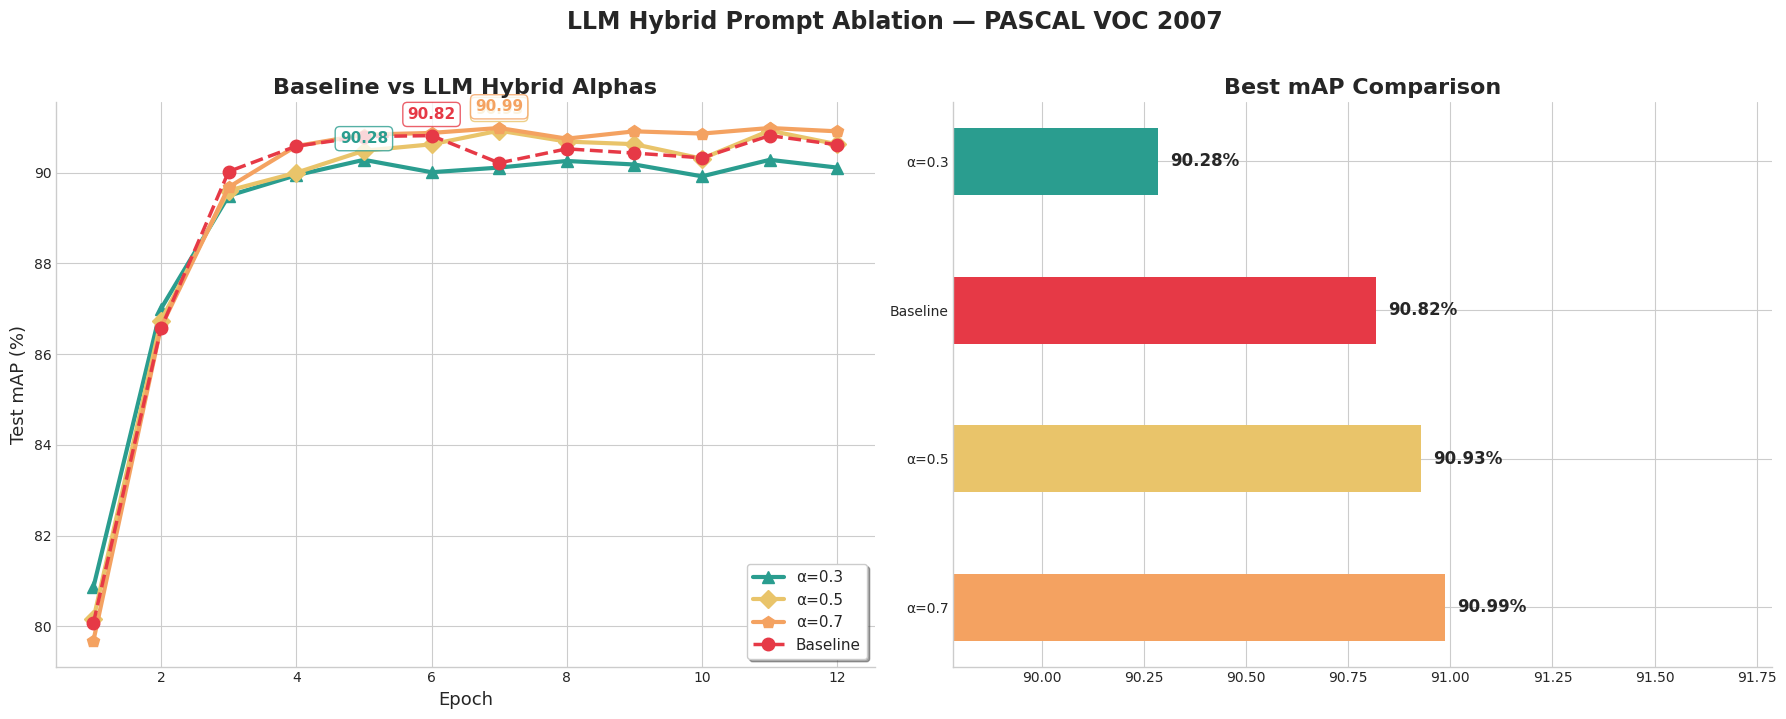


Method                 Best mAP    Δ vs Base
---------------------------------------------
α=0.7                   90.986% +     0.168%
α=0.5                   90.928% +     0.110%
Baseline                90.818% +     0.000%
α=0.3                   90.284%     -0.534%


In [2]:
import os, re, shutil
import matplotlib.pyplot as plt

CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')

# Read all results (using train.log)
results = {}
for alpha in [0.3, 0.5, 0.7]:
    log = f'{CCD_DIR}/results/alpha_{alpha}/train.log'
    if os.path.exists(log):
        with open(log) as f:
            maps = [float(m) for m in re.findall(r'test mAP\s+([\d.]+)', f.read())]
        if maps: results[f'α={alpha}'] = maps

# Also load baseline
for name, folder in [('Baseline', 'baseline')]:
    for logname in ['train.log', 'log.txt']:
        log = f'{CCD_DIR}/results/{folder}/{logname}'
        if os.path.exists(log):
            with open(log) as f:
                maps = [float(m) for m in re.findall(r'test mAP\s+([\d.]+)', f.read())]
            if maps: results[name] = maps; break

# Copy best alpha to llm_hybrid
best_a = '0.7'  # confirmed winner
src = f'{CCD_DIR}/results/alpha_{best_a}'
dst = f'{CCD_DIR}/results/llm_hybrid'
if os.path.exists(dst): shutil.rmtree(dst)
shutil.copytree(src, dst)
print(f"✅ α={best_a} copied to results/llm_hybrid/")

# Plot
colors = {'Baseline':'#E63946','α=0.3':'#2A9D8F','α=0.5':'#E9C46A','α=0.7':'#F4A261'}
markers = {'Baseline':'o','α=0.3':'^','α=0.5':'D','α=0.7':'p'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
plt.style.use('seaborn-v0_8-whitegrid')

for name, maps in results.items():
    ls = '--' if name=='Baseline' else '-'
    lw = 2.5 if name=='Baseline' else 3
    ax1.plot(range(1, len(maps)+1), maps, label=name, color=colors.get(name,'gray'),
            marker=markers.get(name,'o'), markersize=9, linewidth=lw, linestyle=ls)
    best = max(maps)
    ax1.annotate(f'{best:.2f}', xy=(maps.index(best)+1, best), xytext=(0,12),
                textcoords='offset points', ha='center', fontsize=11, fontweight='bold',
                color=colors.get(name,'gray'),
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=colors.get(name,'gray'), alpha=0.8))

ax1.set_title('Baseline vs LLM Hybrid Alphas', fontsize=16, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=13); ax1.set_ylabel('Test mAP (%)', fontsize=13)
ax1.legend(fontsize=11, loc='lower right', frameon=True, shadow=True)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

sorted_r = sorted(results.items(), key=lambda x: max(x[1]), reverse=True)
bar_names = [n for n,_ in sorted_r]
bar_vals = [max(m) for _,m in sorted_r]
bar_cols = [colors.get(n,'gray') for n,_ in sorted_r]
bars = ax2.barh(bar_names, bar_vals, color=bar_cols, height=0.45)
for bar, val in zip(bars, bar_vals):
    ax2.text(bar.get_width()+0.03, bar.get_y()+bar.get_height()/2, f'{val:.2f}%', va='center', fontsize=12, fontweight='bold')
ax2.set_xlim(min(bar_vals)-0.5, max(bar_vals)+0.8)
ax2.set_title('Best mAP Comparison', fontsize=16, fontweight='bold')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

fig.suptitle('LLM Hybrid Prompt Ablation — PASCAL VOC 2007', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{CCD_DIR}/llm_ablation.png', dpi=300, bbox_inches='tight'); plt.show()

baseline_best = max(results.get('Baseline', [0]))
print("\n" + "="*55)
print(f"{'Method':<20} {'Best mAP':>10} {'Δ vs Base':>12}")
print("-"*45)
for name, maps in sorted_r:
    delta = max(maps) - baseline_best
    sign = '+' if delta >= 0 else ''
    print(f"{name:<20} {max(maps):>9.3f}% {sign}{delta:>10.3f}%")
print("="*55)


## Part 4: Contribution 2 — DINOv2 Label Propagation
CLIP understands language but has weak visual features. DINOv2 has the best visual features.
We use DINOv2 to find visually similar images and propagate pseudo-labels between neighbors.

In [5]:
# Step 1: Extract DINOv2 features (~5 min)
import os, torch, numpy as np, torch.nn.functional as F
from PIL import Image
from tqdm import tqdm
from torchvision import transforms

CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
os.chdir(CCD_DIR)

if os.path.exists('dinov2_features.pt'):
    print('DINOv2 features already cached. Skipping.')
else:
    print('Loading DINOv2-ViT-B/14...')
    dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
    dinov2.eval().cuda()
    transform = transforms.Compose([
        transforms.Resize((518, 518)), transforms.CenterCrop(518), transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    train_images = np.load('metadata/voc07/formatted_train_images.npy')
    image_list = [img.strip() for img in train_images]
    all_features = []
    print(f'Extracting features for {len(image_list)} images...')
    for i in tqdm(range(0, len(image_list), 32)):
        batch = [transform(Image.open(os.path.join('data/pascal/JPEGImages', n)).convert('RGB')) for n in image_list[i:i+32]]
        with torch.no_grad(), torch.amp.autocast('cuda'):
            feat = dinov2(torch.stack(batch).cuda())
        all_features.append(F.normalize(feat, dim=-1).cpu())
    all_features = torch.cat(all_features, dim=0)
    torch.save(all_features, 'dinov2_features.pt')
    print(f'✅ Saved: {all_features.shape}')
    del dinov2; torch.cuda.empty_cache()

Loading DINOv2-ViT-B/14...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /teamspace/studios/this_studio/.cache/torch/hub/main.zip


/teamspace/studios/this_studio/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/teamspace/studios/this_studio/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/teamspace/studios/this_studio/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /teamspace/studios/this_studio/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:00<00:00, 544MB/s] 


Extracting features for 5011 images...


100%|██████████| 157/157 [02:38<00:00,  1.01s/it]

✅ Saved: torch.Size([5011, 768])


In [9]:
# Step 2: Build kNN graph (~1 min)
import os, torch
from tqdm import tqdm
CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
os.chdir(CCD_DIR)
feats = torch.load('dinov2_features.pt').cuda()
N, k = feats.shape[0], 10
print(f'Building kNN graph ({N} images, k={k})...')
topk_idx = torch.zeros(N, k, dtype=torch.long)
topk_sim = torch.zeros(N, k)
for i in tqdm(range(0, N, 500)):
    end = min(i+500, N)
    sim = feats[i:end] @ feats.T
    for j in range(end-i): sim[j, i+j] = -1
    vals, idx = sim.topk(k, dim=1)
    topk_idx[i:end] = idx.cpu()
    topk_sim[i:end] = vals.cpu()
torch.save({'topk_indices': topk_idx, 'topk_sims': topk_sim, 'k': k, 'alpha': 0.4, 'temperature': 0.1}, 'dinov2_propagation_data.pt')
print(f'✅ kNN graph saved! Avg top-1 sim: {topk_sim[:,0].mean():.3f}')
del feats; torch.cuda.empty_cache()

Building kNN graph (5011 images, k=10)...


100%|██████████| 11/11 [00:00<00:00, 76.29it/s]

✅ kNN graph saved! Avg top-1 sim: 0.617


In [30]:
import os
CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
os.chdir(CCD_DIR)

with open('train.py', 'r') as f:
    lines = f.readlines()

# Remove the broken DINOv2 patch
new_lines = []
skip = False
for line in lines:
    if 'DINOV2 LABEL PROPAGATION' in line:
        skip = True
        continue
    if skip and line.strip() == '':
        skip = False
        continue
    if skip and ('_pd' in line or '_idx' in line or '_sim' in line or '_a, _t' in line 
                 or '_ps' in line or '_N =' in line or '_ki' in line or '_ks' in line
                 or '_w =' in line or '_nl' in line or '_wn' in line or '_prop' in line
                 or 'DINOV2' in line or 'table_pseudolabel[_i]' in line):
        continue
    if 'DINOV2_PROP_PATH' in line and 'dinov2_propagation_data' in line:
        continue
    new_lines.append(line)

# Now find the correct insertion point — BEFORE the 'with' that wraps the training loop
code = ''.join(new_lines)
lines = new_lines

# Find "for batch in tqdm(dataloader[phase]):" and go UP to find the 'with' above it
marker_idx = None
for i, line in enumerate(lines):
    if 'for batch in tqdm(dataloader[phase]):' in line:
        # Go up to find the 'with' statement
        for j in range(i-1, max(i-5, 0), -1):
            if 'with' in lines[j] and ':' in lines[j]:
                marker_idx = j  # insert BEFORE the 'with'
                break
        if marker_idx is None:
            marker_idx = i  # fallback: insert before for loop
        break

if marker_idx:
    ind = '        '
    prop_lines = [
        ind + "# === DINOV2 LABEL PROPAGATION (Novel Contribution) ===\n",
        ind + "if epoch == 0 and phase == 'train' and 'DINOV2_PROP_PATH' in dir() and os.path.exists(DINOV2_PROP_PATH):\n",
        ind + "    _pd = torch.load(DINOV2_PROP_PATH, map_location='cpu')\n",
        ind + "    _idx, _sim = _pd['topk_indices'], _pd['topk_sims']\n",
        ind + "    _a, _t = _pd.get('alpha', 0.4), _pd.get('temperature', 0.1)\n",
        ind + "    _ps = torch.stack(table_pseudolabel, dim=0).squeeze(1)\n",
        ind + "    _N = min(_ps.shape[0], _idx.shape[0])\n",
        ind + "    _ki = _idx[:_N].clamp(0, _N-1)\n",
        ind + "    _ks = _sim[:_N]\n",
        ind + "    _w = torch.softmax(_ks / _t, dim=1)\n",
        ind + "    _nl = _ps[_ki]\n",
        ind + "    _wn = (_w.unsqueeze(-1) * _nl).sum(dim=1)\n",
        ind + "    _prop = (1 - _a) * _ps[:_N] + _a * _wn\n",
        ind + "    for _i in range(_N): table_pseudolabel[_i] = _prop[_i].unsqueeze(0)\n",
        ind + "    print(f'[DINOV2] Done! alpha={_a}, delta={(_prop - _ps[:_N]).abs().mean():.4f}')\n",
        "\n",
    ]
    
    # Add constant at top if needed
    header = "DINOV2_PROP_PATH = os.path.join(os.path.dirname(os.path.abspath(__file__)), 'dinov2_propagation_data.pt')\n"
    if 'DINOV2_PROP_PATH' not in ''.join(lines):
        lines.insert(0, header)
        marker_idx += 1

    for j, pline in enumerate(prop_lines):
        lines.insert(marker_idx + j, pline)
    
    with open('train.py', 'w') as f:
        f.writelines(lines)
    print(f'✅ train.py fixed and re-patched! (inserted before line {marker_idx})')
else:
    print('❌ Could not find training loop.')


✅ train.py fixed and re-patched! (inserted before line 376)


Current structure:
   361 (ind= 0): 
   362 (ind= 8):         for phase in ['train', 'val']:
   363 (ind=12):             if phase == 'train':
   364 (ind=16):                 model.train()
   365 (ind=16):                 train_batch_count = 0
   366 (ind=16):                 batch_stack = 0
   367 (ind=16):                 train_loss = 0
   368 (ind=16):                 y_train_pred = np.zeros((len(dataset[phase]), P['num_classe
   369 (ind=16):                 y_train_lab = np.zeros((len(dataset[phase]), P['num_classes
   370 (ind= 0): 
   371 (ind=12):             else:
   372 (ind=16):                 model.eval()
   373 (ind=16):                 y_pred = np.zeros((len(dataset[phase]), P['num_classes']))
   374 (ind=16):                 y_true = np.zeros((len(dataset[phase]), P['num_classes']))
   375 (ind=16):                 batch_stack = 0
   376 (ind= 0): 
   377 (ind= 8):         # === DINOV2 LABEL PROPAGATION (Novel Contribution) ===
   378 (ind= 8):         if epoch == 0 an

In [33]:
import os, subprocess
CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
os.chdir(CCD_DIR)

# Restore original train.py from git
subprocess.run(['git', 'checkout', 'train.py'], check=True)
print("✅ train.py restored to original!")

# Now apply BOTH patches cleanly in one go
with open('train.py', 'r') as f:
    code = f.read()

# 1. Add DINOV2 constant after 'import os'
code = code.replace(
    'import os\n',
    "import os\nDINOV2_PROP_PATH = os.path.join(os.path.dirname(os.path.abspath(__file__)), 'dinov2_propagation_data.pt')\n",
    1
)

# 2. Add LLM embedding loading before CLIP text encoding
old_block = "    with torch.no_grad(), torch.cuda.amp.autocast():"
new_block = """    # === LLM-ENRICHED EMBEDDINGS (Novel Contribution 1) ===
    enriched_path = os.path.join(os.path.dirname(os.path.abspath(__file__)), 'enriched_embeddings_voc07.pt')
    if os.path.exists(enriched_path):
        print(f'[LLM] Loading enriched embeddings from {enriched_path}')
        emb_data = torch.load(enriched_path, map_location=device)
        text_weights = emb_data['text_weights'].to(device).permute(1, 0)
        print(f'[LLM] Loaded shape: {text_weights.shape}')
    else:
        print('[BASELINE] Using standard CLIP prompts')
        with torch.no_grad(), torch.cuda.amp.autocast():"""
code = code.replace(old_block, new_block, 1)

# Also need to keep the rest of the text encoding in the else block
# Find 'text_weights = text_weights.permute(1, 0)' and add proper closing
code = code.replace(
    "        text_weights = text_weights.permute(1, 0)",
    "        text_weights = text_weights.permute(1, 0)\n        # end of baseline text encoding"
)

# 3. Add DINOv2 propagation before the training loop
old_train = "            with torch.set_grad_enabled(phase == 'train'):"
new_train = """            # === DINOV2 LABEL PROPAGATION (Novel Contribution 2) ===
            if epoch == 0 and phase == 'train' and os.path.exists(DINOV2_PROP_PATH):
                print('[DINOV2] Propagating labels via visual similarity...')
                _pd = torch.load(DINOV2_PROP_PATH, map_location='cpu')
                _idx, _sim = _pd['topk_indices'], _pd['topk_sims']
                _a, _t = _pd.get('alpha', 0.4), _pd.get('temperature', 0.1)
                _ps = torch.stack(table_pseudolabel, dim=0).squeeze(1)
                _N = min(_ps.shape[0], _idx.shape[0])
                _ki = _idx[:_N].clamp(0, _N-1)
                _ks = _sim[:_N]
                _w = torch.softmax(_ks / _t, dim=1)
                _nl = _ps[_ki]
                _wn = (_w.unsqueeze(-1) * _nl).sum(dim=1)
                _prop = (1 - _a) * _ps[:_N] + _a * _wn
                for _i in range(_N): table_pseudolabel[_i] = _prop[_i].unsqueeze(0)
                _delta = (_prop - _ps[:_N]).abs().mean()
                print(f'[DINOV2] Done! alpha={_a}, delta={_delta:.4f}')

            with torch.set_grad_enabled(phase == 'train'):"""
code = code.replace(old_train, new_train, 1)

with open('train.py', 'w') as f:
    f.write(code)

print("✅ Both LLM + DINOv2 patches applied cleanly!")
print("\nVerifying structure...")
with open('train.py', 'r') as f:
    vlines = f.readlines()
for i, line in enumerate(vlines):
    if any(x in line for x in ['DINOV2_PROP_PATH =', 'LLM-ENRICHED', 'DINOV2 LABEL', 'set_grad_enabled', 'for batch in tqdm']):
        ind = len(line) - len(line.lstrip())
        print(f"  Line {i+1} (ind={ind}): {line.rstrip()[:70]}")


✅ train.py restored to original!
✅ Both LLM + DINOv2 patches applied cleanly!

Verifying structure...
  Line 7 (ind=0): DINOV2_PROP_PATH = os.path.join(os.path.dirname(os.path.abspath(__file
  Line 141 (ind=4):     # === LLM-ENRICHED EMBEDDINGS (Novel Contribution 1) ===
  Line 376 (ind=12):             # === DINOV2 LABEL PROPAGATION (Novel Contribution 2) ===
  Line 394 (ind=12):             with torch.set_grad_enabled(phase == 'train'):
  Line 395 (ind=16):                 for batch in tqdm(dataloader[phase]):


Updated 1 path from the index


In [35]:
import os
CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')

with open(f'{CCD_DIR}/train.py', 'r') as f:
    lines = f.readlines()

# Fix: the 'with torch.set_grad_enabled' (line 393) needs to be
# at the SAME indent level as the DINOv2 'if' block, not inside it.
# Currently:  12 spaces (inside the if)
# Should be:  8 spaces  (same level as the if)

fixed = False
for i, line in enumerate(lines):
    if 'with torch.set_grad_enabled' in line and i > 370:
        # Check if it's over-indented (12 spaces instead of 8)
        current_indent = len(line) - len(line.lstrip())
        if current_indent > 8:
            # Fix this line and all subsequent lines in the block
            # by removing 4 spaces of extra indentation
            print(f"Found over-indented 'with' at line {i+1} (indent={current_indent})")
            # Remove 4 spaces from line 393 onwards until we hit a line
            # that's back at 8-space indent or less
            j = i
            while j < len(lines):
                stripped = lines[j].rstrip('\n')
                if stripped == '':
                    j += 1
                    continue
                indent = len(stripped) - len(stripped.lstrip())
                if indent >= 12 and j >= i:
                    lines[j] = lines[j][4:]  # remove 4 leading spaces
                    j += 1
                elif j > i and indent <= 8:
                    break  # back to normal indent, stop
                else:
                    j += 1
            fixed = True
            break

if fixed:
    with open(f'{CCD_DIR}/train.py', 'w') as f:
        f.writelines(lines)
    print('✅ Fixed! Training loop is now outside the DINOv2 if-block.')
    
    # Verify
    with open(f'{CCD_DIR}/train.py', 'r') as f:
        vlines = f.readlines()
    for i, line in enumerate(vlines):
        if any(x in line for x in ['DINOV2 LABEL', 'set_grad_enabled', 'for batch in tqdm']):
            indent = len(line) - len(line.lstrip())
            print(f"  Line {i+1} (indent={indent}): {line.rstrip()[:70]}")
else:
    print('Could not find the over-indented block.')


Found over-indented 'with' at line 394 (indent=12)
✅ Fixed! Training loop is now outside the DINOv2 if-block.
  Line 376 (indent=12):             # === DINOV2 LABEL PROPAGATION (Novel Contribution 2) ===
  Line 394 (indent=8):         with torch.set_grad_enabled(phase == 'train'):
  Line 395 (indent=12):             for batch in tqdm(dataloader[phase]):


In [37]:
import os, subprocess
CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
os.chdir(CCD_DIR)
subprocess.run(['git', 'checkout', 'train.py'], check=True)
print("✅ train.py restored to original from git!")


✅ train.py restored to original from git!


Updated 1 path from the index


Line 141: [    with torch.no_grad(), torch.cuda.amp.autocast():]
Line 142: [        text_weights = []]
Line 143: [        for classname in pascal_classes:]
Line 144: []
Line 145: [            texts = [template.format(classname) for template in templates]]
Line 146: [            texts = clip.tokenize(texts).to(device)]



In [40]:

import os
CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
os.chdir(CCD_DIR)

with open('train.py', 'r') as f:
    lines = f.readlines()

# Find the autocast + text_weights block
done = False
for i, line in enumerate(lines):
    if 'torch.no_grad()' in line and 'autocast()' in line:
        # Check if this is the text encoding block (text_weights nearby)
        nearby = ''.join(lines[i:i+8])
        if 'text_weights' in nearby:
            # Insert LLM block BEFORE this line
            indent = '    '
            insert = [
                indent + "# === LLM-ENRICHED EMBEDDINGS (Contribution 1) ===\n",
                indent + "enriched_path = os.path.join(os.path.dirname(os.path.abspath(__file__)), 'enriched_embeddings_voc07.pt')\n",
                indent + "if os.path.exists(enriched_path):\n",
                indent + "    emb_data = torch.load(enriched_path, map_location=device)\n",
                indent + "    text_weights = emb_data['text_weights'].to(device).permute(1, 0)\n",
                indent + "    print(f'[LLM] Loaded enriched embeddings: {text_weights.shape}')\n",
                indent + "else:\n",
                indent + "    print('[BASELINE] Using standard CLIP prompts')\n",
            ]
            # Add extra indent to original block (put it inside 'else')
            j = i
            end_j = j
            while j < len(lines):
                if 'text_weights.permute(1, 0)' in lines[j]:
                    end_j = j
                    break
                j += 1
            
            # Indent original lines under 'else'
            for k in range(i, end_j + 1):
                lines[k] = '    ' + lines[k]
            
            # Insert new block
            for idx, ins_line in enumerate(insert):
                lines.insert(i + idx, ins_line)
            
            done = True
            break

if done:
    with open('train.py', 'w') as f:
        f.writelines(lines)
    print("✅ LLM patch applied!")
else:
    print("❌ Could not find text encoding block")


✅ LLM patch applied!


In [41]:
import os
CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
with open(f'{CCD_DIR}/train.py', 'r') as f:
    lines = f.readlines()
keywords = ['DINOV2_PROP_PATH =', 'LLM-ENRICHED', 'enriched_path', 'DINOV2 LABEL',
            'set_grad_enabled', 'for batch in tqdm', 'for phase in', 'meanloss']
for i, line in enumerate(lines):
    if any(x in line for x in keywords):
        ind = len(line) - len(line.lstrip())
        print(f"  Line {i+1} (ind={ind}): {line.rstrip()[:70]}")

  Line 7 (ind=0): DINOV2_PROP_PATH = os.path.join(os.path.dirname(os.path.abspath(__file
  Line 125 (ind=4):     for phase in ['infer', 'val']:
  Line 141 (ind=4):     # === LLM-ENRICHED EMBEDDINGS (Contribution 1) ===
  Line 142 (ind=4):     enriched_path = os.path.join(os.path.dirname(os.path.abspath(__fil
  Line 143 (ind=4):     if os.path.exists(enriched_path):
  Line 144 (ind=8):         emb_data = torch.load(enriched_path, map_location=device)
  Line 359 (ind=8):         for phase in ['train', 'val']:
  Line 374 (ind=12):             # === DINOV2 LABEL PROPAGATION (Contribution 2) ===
  Line 392 (ind=12):             with torch.set_grad_enabled(phase == 'train'):
  Line 393 (ind=16):                 for batch in tqdm(dataloader[phase]):
  Line 459 (ind=8):         meanloss = train_loss / train_batch_count
  Line 460 (ind=8):         logger.info(f"Epoch {epoch} : loss mean {meanloss}")


✅ Fixed device mismatch! Now re-run training.


In [44]:
import os, shutil
CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
os.chdir(CCD_DIR)
if os.path.exists('enriched_embeddings_voc07.pt'): os.remove('enriched_embeddings_voc07.pt')
!CUDA_VISIBLE_DEVICES=0 python main_multi.py \
    --dataset voc07 --num_epochs 10 --bsize 16 --lr 1e-5 \
    --offset_size 80 --coeff 3 --loss_coeff 1 --ratio 0.2 \
    --box_offset 80 --topk 1 --LS True --LS_coeff 20 --bound 4
results_dir = os.path.join(CCD_DIR, 'results')
folders = sorted([f for f in os.listdir(results_dir) if f.startswith('202')])
if folders:
    dst = os.path.join(results_dir, 'dinov2_only')
    if os.path.exists(dst): shutil.rmtree(dst)
    shutil.move(os.path.join(results_dir, folders[-1]), dst)
    print('✅ DINOv2-only results saved!')

/teamspace/studios/this_studio/CCD_Project/CCD/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging
Munch({'dataset': 'voc07', 'num_epochs': 10, 'gpu_num': '0', 'bsize': 16, 'lr': 1e-05, 'offset_size': 80, 'coeff': 3.0, 'loss_coeff': 1.0, 'ratio': 0.2, 'colorjitter': True, 'update_label': True, 'train_resize': (448, 448), 'patch_resize': (640, 640), 'box_offset': 80, 'topk': 1, 'LS': True, 'coeff_bias': False, 'method': 'cam_based', 'arch': 'resnet101', 'inf_num': 1, 'global_temp': True, 'local_temp': True, 'use_consist': 1, 'LS_coeff': 20, 'bound': 4, 'ss_seed': 999, 'ss_frac_train': 1.0, 'ss_frac_val': 1.0, 'use_feats': False, 'val_frac': 0.2, 'split_seed': 1200, 'train_set_variant': 'observed', 'val_set_variant': 'clean', 'freeze_feature_extrac

## Part 5: Contribution 3 — Combined LLM + DINOv2

In [45]:
import os, shutil
CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
os.chdir(CCD_DIR)
shutil.copy('enriched_embeddings_voc07_alpha0.7.pt', 'enriched_embeddings_voc07.pt')
print('LLM=alpha0.7 + DINOv2=enabled')
!CUDA_VISIBLE_DEVICES=0 python main_multi.py \
    --dataset voc07 --num_epochs 10 --bsize 16 --lr 1e-5 \
    --offset_size 80 --coeff 3 --loss_coeff 1 --ratio 0.2 \
    --box_offset 80 --topk 1 --LS True --LS_coeff 20 --bound 4
results_dir = os.path.join(CCD_DIR, 'results')
folders = sorted([f for f in os.listdir(results_dir) if f.startswith('202')])
if folders:
    dst = os.path.join(results_dir, 'llm_dinov2_combined')
    if os.path.exists(dst): shutil.rmtree(dst)
    shutil.move(os.path.join(results_dir, folders[-1]), dst)
    print('✅ Combined results saved!')

LLM=alpha0.7 + DINOv2=enabled
/teamspace/studios/this_studio/CCD_Project/CCD/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging
Munch({'dataset': 'voc07', 'num_epochs': 10, 'gpu_num': '0', 'bsize': 16, 'lr': 1e-05, 'offset_size': 80, 'coeff': 3.0, 'loss_coeff': 1.0, 'ratio': 0.2, 'colorjitter': True, 'update_label': True, 'train_resize': (448, 448), 'patch_resize': (640, 640), 'box_offset': 80, 'topk': 1, 'LS': True, 'coeff_bias': False, 'method': 'cam_based', 'arch': 'resnet101', 'inf_num': 1, 'global_temp': True, 'local_temp': True, 'use_consist': 1, 'LS_coeff': 20, 'bound': 4, 'ss_seed': 999, 'ss_frac_train': 1.0, 'ss_frac_val': 1.0, 'use_feats': False, 'val_frac': 0.2, 'split_seed': 1200, 'train_set_variant': 'observed', 'val_set_variant': '

## Part 6: Final Results & Visualization

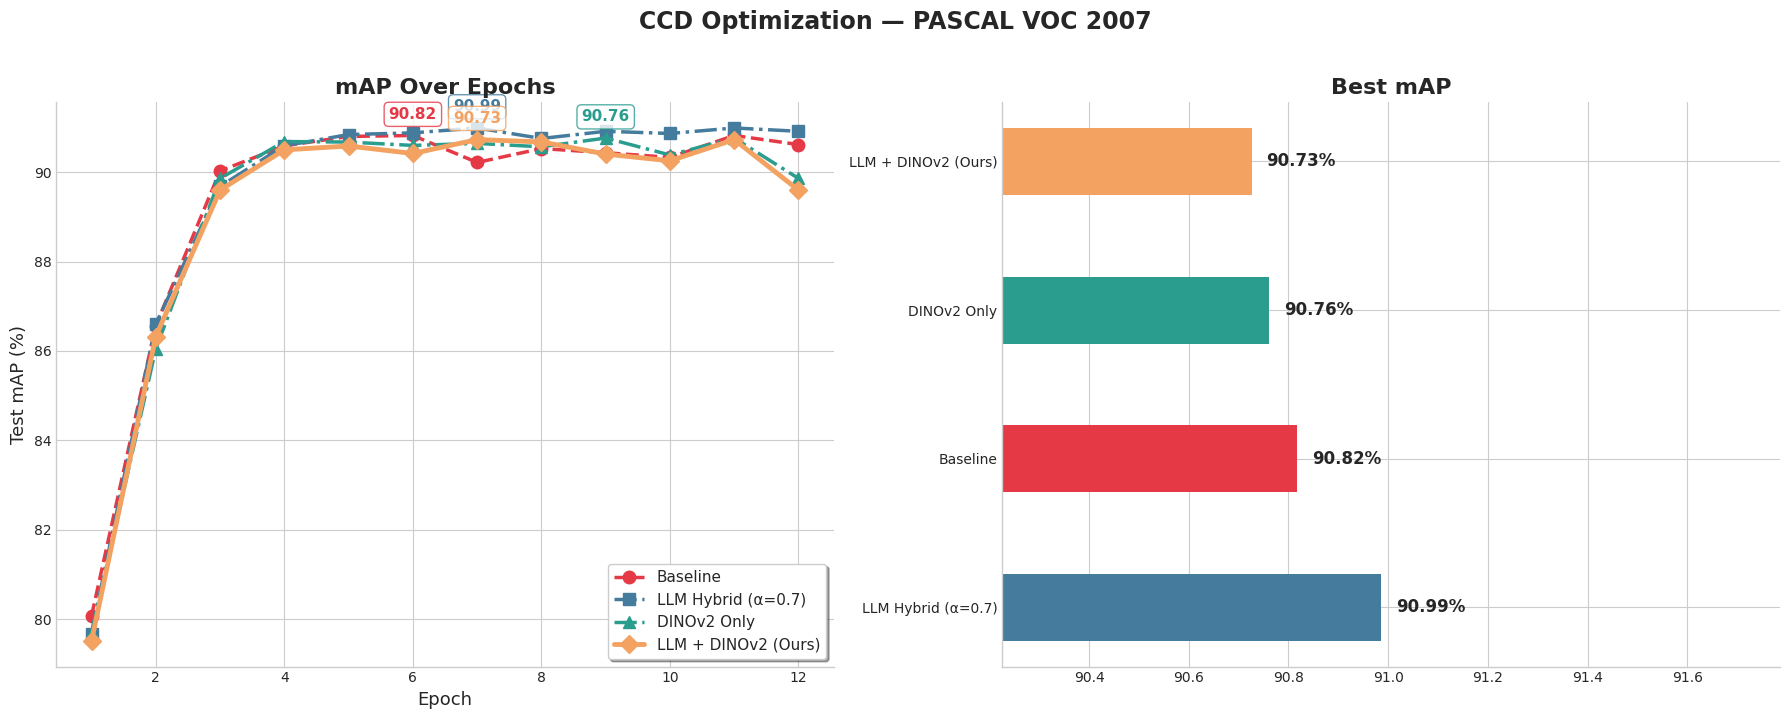


LLM Hybrid (α=0.7)           90.986% +     0.168%
Baseline                     90.818% +     0.000%
DINOv2 Only                  90.761%     -0.057%
LLM + DINOv2 (Ours)          90.726%     -0.092%


In [3]:
import os, re
import matplotlib.pyplot as plt
CCD_DIR = os.path.expanduser('~/CCD_Project/CCD')
experiments = {
    'Baseline': 'baseline',
    'LLM Hybrid (α=0.7)': 'llm_hybrid',
    'DINOv2 Only': 'dinov2_only',
    'LLM + DINOv2 (Ours)': 'llm_dinov2_combined',
}
results = {}
for name, folder in experiments.items():
    for logname in ['train.log', 'log.txt']:
        log = f'{CCD_DIR}/results/{folder}/{logname}'
        if os.path.exists(log):
            with open(log) as f:
                maps = [float(m) for m in re.findall(r'test mAP\s+([\d.]+)', f.read())]
            if maps: results[name] = maps; break
colors = {'Baseline':'#E63946','LLM Hybrid (α=0.7)':'#457B9D','DINOv2 Only':'#2A9D8F','LLM + DINOv2 (Ours)':'#F4A261'}
markers = {'Baseline':'o','LLM Hybrid (α=0.7)':'s','DINOv2 Only':'^','LLM + DINOv2 (Ours)':'D'}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
plt.style.use('seaborn-v0_8-whitegrid')
for name, maps in results.items():
    ls = '--' if name=='Baseline' else ('-' if 'Ours' in name else '-.')
    lw = 3.5 if 'Ours' in name else 2.5
    ax1.plot(range(1,len(maps)+1), maps, label=name, color=colors[name],
            marker=markers[name], markersize=9, linewidth=lw, linestyle=ls)
    best = max(maps)
    ax1.annotate(f'{best:.2f}', xy=(maps.index(best)+1, best), xytext=(0,12),
                textcoords='offset points', ha='center', fontsize=11, fontweight='bold',
                color=colors[name], bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=colors[name], alpha=0.8))
ax1.set_title('mAP Over Epochs', fontsize=16, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=13); ax1.set_ylabel('Test mAP (%)', fontsize=13)
ax1.legend(fontsize=11, loc='lower right', frameon=True, shadow=True)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
sorted_r = sorted(results.items(), key=lambda x: max(x[1]), reverse=True)
bars = ax2.barh([n for n,_ in sorted_r], [max(m) for _,m in sorted_r],
               color=[colors[n] for n,_ in sorted_r], height=0.45)
for bar, val in zip(bars, [max(m) for _,m in sorted_r]):
    ax2.text(bar.get_width()+0.03, bar.get_y()+bar.get_height()/2, f'{val:.2f}%', va='center', fontsize=12, fontweight='bold')
ax2.set_xlim(min(max(m) for _,m in sorted_r)-0.5, max(max(m) for _,m in sorted_r)+0.8)
ax2.set_title('Best mAP', fontsize=16, fontweight='bold')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
fig.suptitle('CCD Optimization — PASCAL VOC 2007', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{CCD_DIR}/final_results.png', dpi=300, bbox_inches='tight'); plt.show()
base = max(results.get('Baseline',[0]))
print("\n" + "="*55)
for n, m in sorted_r:
    d = max(m) - base; s = '+' if d>=0 else ''
    print(f"{n:<25} {max(m):>9.3f}% {s}{d:>10.3f}%")
print("="*55)